In [3]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt


##### Generate Synthetic House Pricing Data

In [ ]:

# Step 1: LoRA Implementation for Regression Task
# Generate synthetic data for house prices
np.random.seed(42) # ✨with seed 42 we will get same random numbers every time, without seed we will get different random numbers every time
num_samples = 500

# Features: house size (sq ft) and location index
X = np.random.rand(num_samples, 2) * 100 # means 500 samples with 2 features each 

# True price equation:
# Price = 50 * Size + 30 * Location + Noise

y = 50 * X[:, 0] + 30 * X[:, 1] + np.random.randn(num_samples) * 10
# [:,0] means all rows and first column
y = y.reshape(-1, 1)

# Split into training and test sets
train_size = int(0.8 * num_samples)
X_train, y_train = X[:train_size], y[:train_size] # meaning first 400 samples , 0 to 399
X_test, y_test = X[train_size:], y[train_size:] # meaning last 100 samples , 400 to 499

print(f"Training Samples: {X_train.shape}, Test Samples: {X_test.shape}")



# Define LoRA Layer
# -------------------------------------------------------------

"""
How This Works:

- W is frozen (not updated during training).
- A and B are trained, capturing task-specific knowledge.
- The LoRA update A · B adapts the model with fewer parameters.
"""

class LoRALayer(tf.keras.layers.Layer):
    def __init__(self, input_dim, output_dim, rank=2, alpha=1.0):
        super(LoRALayer, self).__init__()
        self.rank = rank
        self.alpha = alpha  # scaling factor

        # Main frozen weight matrix
        self.W = self.add_weight(
            shape=(input_dim, output_dim),
            initializer="random_normal",
            trainable=False # W is frozen so cannot be trained
        )

        # LoRA trainable low-rank matrices
        self.A = self.add_weight(
            shape=(input_dim, rank),
            initializer="random_normal",
            trainable=True
        )
        self.B = self.add_weight(
            shape=(rank, output_dim),
            initializer="random_normal",
            trainable=True
        )

    def call(self, inputs):
        # LoRA update: XAB * alpha
        lora_update = tf.matmul(inputs, self.A)
        lora_update = tf.matmul(lora_update, self.B) * self.alpha

        # Final output: XW + XABα
        return tf.matmul(inputs, self.W) + lora_update
        # X (W + AB α)





seed value,None
Training Samples: (400, 2), Test Samples: (100, 2)
Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 2)]               0         
                                                                 
 lo_ra_layer_3 (LoRALayer)   (None, 16)                68        
                                                                 
 re_lu_3 (ReLU)              (None, 16)                0         
                                                                 
 dense_3 (Dense)             (None, 1)                 17        
                                                                 
Total params: 85
Trainable params: 53
Non-trainable params: 32
_________________________________________________________________
Epoch 1/100
25/25 [==============================] - 0s 7ms/step - loss: 18313432.0000 - val_loss: 15832579.0000
Epoch 2/100
25

##### Evaluate Performance

Test Loss (MSE): 95.54132843017578


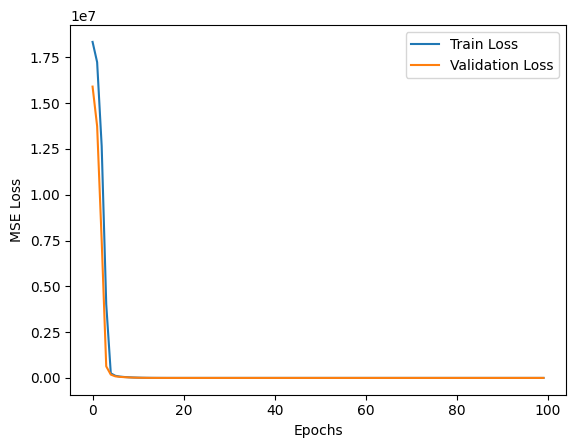